In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df= pd.read_csv("dataset/IMDb Movies India.csv",encoding='latin1')
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [34]:
df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [35]:
df=df.dropna()
df.isnull().sum()

Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

In [36]:
df=df[['Genre','Director','Actor 1','Actor 2','Actor 3','Rating']]

In [37]:
from sklearn.preprocessing import LabelEncoder

le= LabelEncoder()

df['Genre']=le.fit_transform(df['Genre'])
df['Director']=le.fit_transform(df['Director'])
df['Actor 1']=le.fit_transform(df['Actor 1'])
df['Actor 2']=le.fit_transform(df['Actor 2'])
df['Ator 3']=le.fit_transform(df['Actor 3'])

In [45]:
df=df.loc[:, ~df.columns.duplicated()]

In [46]:
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

df = df.dropna()

In [65]:
print(type(y))
print(y.head())

<class 'pandas.core.series.Series'>
1    7.0
3    4.4
5    4.7
6    7.4
8    5.6
Name: Rating, dtype: float64


In [66]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
for column in['Genre','Director','Actor 1','Actor 2','Actor 3']:
    df[column]=le.fit_transform(df[column].astype(str))

In [67]:
x=df[['Genre','Director','Actor 1','Actor 2','Actor 3']]
y=df['Rating'].astype(float)

In [68]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [69]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [70]:
y_pred=model.predict(X_test)

In [71]:
from sklearn.metrics import mean_absolute_error

mae= mean_absolute_error(y_test,y_pred)
print("Mean Absolute Error:",mae)

Mean Absolute Error: 1.055410836277974


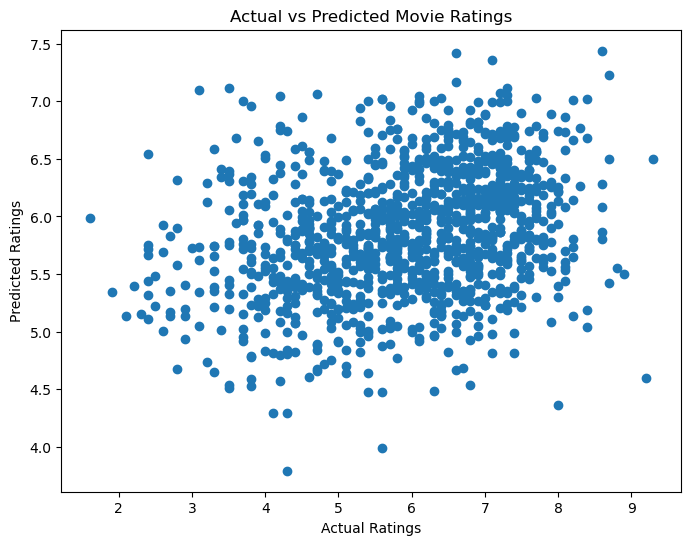

In [72]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Movie Ratings")

plt.show()

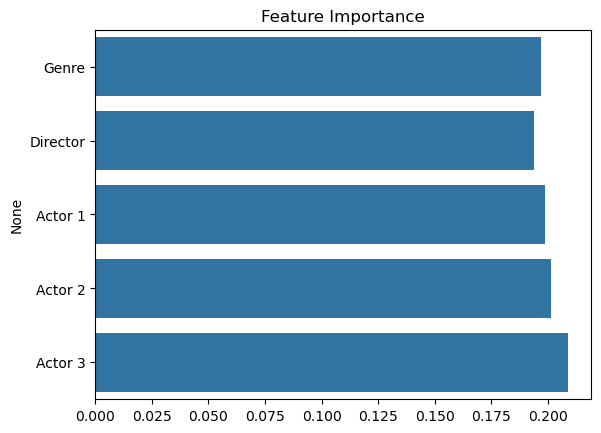

In [74]:
importance=model.feature_importances_
features = x.columns

sns.barplot(x=importance,y=features)
plt.title("Feature Importance")
plt.show()